In [27]:
#%pip install category_encoders
#import libraries
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from category_encoders import OrdinalEncoder
from IPython.display import VimeoVideo
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [37]:
#create a data cleaning pipeline
def wrangle(file_path):
    # load the data
    df = pd.read_csv(file_path)

    #Drop high cardinality variable
    df.drop(columns=["applicant_id"], inplace=True)

    return df

In [38]:
df = wrangle("C:\AGGREY_RAISING THE VILLAGE\Test Data\loanapproval.csv")
df.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1 to 1000
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   1000 non-null   int64 
 1   gender                1000 non-null   object
 2   marital_status        1000 non-null   object
 3   annual_income         1000 non-null   int64 
 4   loan_amount           1000 non-null   int64 
 5   credit_score          1000 non-null   int64 
 6   num_dependents        1000 non-null   int64 
 7   existing_loans_count  1000 non-null   int64 
 8   employment_status     1000 non-null   object
 9   loan_approved         1000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 85.9+ KB


In [ ]:
#select the numeric columns
num_cols = df.select_dtypes("number").drop(columns="loan_approved")
num_cols.head()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count
applicant_id,,,,,,
1,59,100073,7169,793,1,1
2,49,112197,23556,789,0,2
3,35,84429,27052,372,1,4
4,63,124195,11313,808,3,4
5,28,81627,13315,689,0,1


<Axes: >

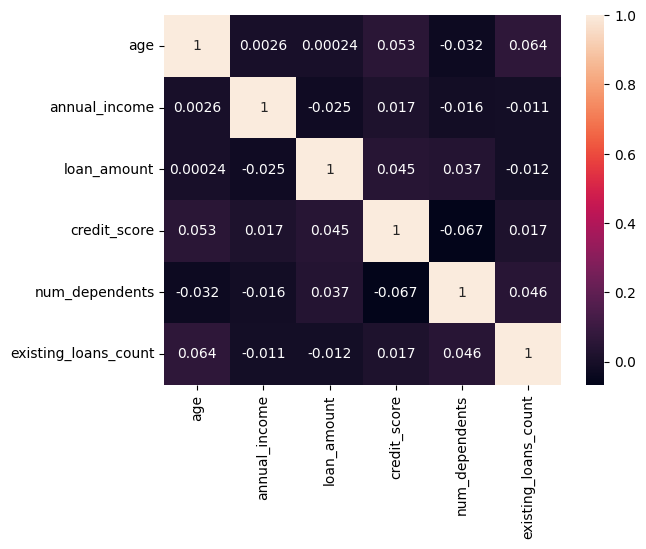

In [ ]:
#Testing for multicollinearity
correlation=num_cols.corr()
#correlation
sns.heatmap(correlation, annot=True)

existing_loans_count    Axes(0.125,0.53;0.227941x0.35)
dtype: object

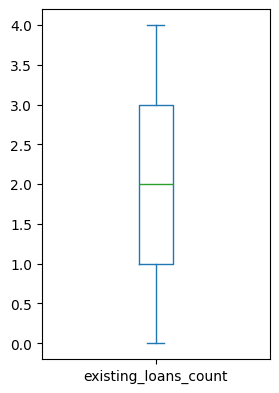

In [34]:
num_cols["existing_loans_count"].plot(kind="box", subplots=True, layout=(2,3), figsize=(10,10))

In [45]:
cat_cols = df.select_dtypes("object")
print(cat_cols["gender"].value_counts())
print(cat_cols["marital_status"].value_counts())
print(cat_cols["employment_status"].value_counts())

gender
Male      524
Female    476
Name: count, dtype: int64
marital_status
Married     355
Single      342
Divorced    303
Name: count, dtype: int64
employment_status
Self-employed    350
Unemployed       330
Employed         320
Name: count, dtype: int64


In [52]:
mstatus_pivot = pd.pivot_table(
      df, index="marital_status", values="loan_approved", aggfunc=np.mean
      ).sort_values(by="loan_approved")
mstatus_pivot

,loan_approved
marital_status,
Single,0.701754
Divorced,0.716172
Married,0.766197


In [53]:
emptatus_pivot = pd.pivot_table(
      df, index="employment_status", values="loan_approved", aggfunc=np.mean
      ).sort_values(by="loan_approved")
emptatus_pivot

,loan_approved
employment_status,
Unemployed,0.512121
Employed,0.815625
Self-employed,0.854286


In [54]:
gender_pivot = pd.pivot_table(
      df, index="gender", values="loan_approved", aggfunc=np.mean
      ).sort_values(by="loan_approved")
gender_pivot

,loan_approved
gender,
Female,0.720588
Male,0.736641


In [55]:
df["loan_approved"].value_counts(normalize=True)

loan_approved
1    0.729
0    0.271
Name: proportion, dtype: float64

In [56]:
# Splitting the data into feature matrix and target vector
target = "loan_approved"
X = df.drop(columns=target)
y = df[target]

In [ ]:
#Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [58]:
#Further split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [59]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.73


In [66]:
# Build model pipeline - Decision Tree Classifier
model = make_pipeline(
    OrdinalEncoder(),DecisionTreeClassifier(max_depth=5,random_state=42)
)
# Fit model to training data
model.fit(X_train, y_train)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(cols=['gender', 'marital_status',
                                      'employment_status'],
                                mapping=[{'col': 'gender',
                                          'data_type': dtype('O'),
                                          'mapping': Male      1
Female    2
NaN      -2
dtype: int64},
                                         {'col': 'marital_status',
                                          'data_type': dtype('O'),
                                          'mapping': Divorced    1
Single      2
Married     3
NaN        -2
dtype: int64},
                                         {'col': 'employment_status',
                                          'data_type': dtype('O'),
                                          'mapping': Self-employed    1
Employed         2
Unemployed       3
NaN             -2
dtype: int64}])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [67]:
# Model evaluation
acc_train = accuracy_score(y_train,model.predict(X_train))
acc_val = model.score(X_val,y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))


Training Accuracy: 1.0
Validation Accuracy: 1.0


In [62]:
tree_depth = model.named_steps["decisiontreeclassifier"].get_depth()
tree_depth

5

In [63]:
#Hyperparameter tuning - max_depth
depth_hyperparams = range(1,50,2)
depth_hyperparams

range(1, 50, 2)

In [64]:
# Testing to get optimal tree depth
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # Create model with `max_depth` of `d`
    test_model = make_pipeline(
        OrdinalEncoder(), DecisionTreeClassifier(max_depth=d, random_state=42)
    )
    # Fit model to training data
    test_model.fit(X_train, y_train)
    # Calculate training accuracy score and append to `training_acc`
    
    training_acc.append(accuracy_score(y_train,test_model.predict(X_train)))
    # Calculate validation accuracy score and append to `training_acc`
    
    validation_acc.append(test_model.score(X_val,y_val))

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.7390625, 0.85625, 1.0]
Validation Accuracy Scores: [0.76875, 0.90625, 1.0]


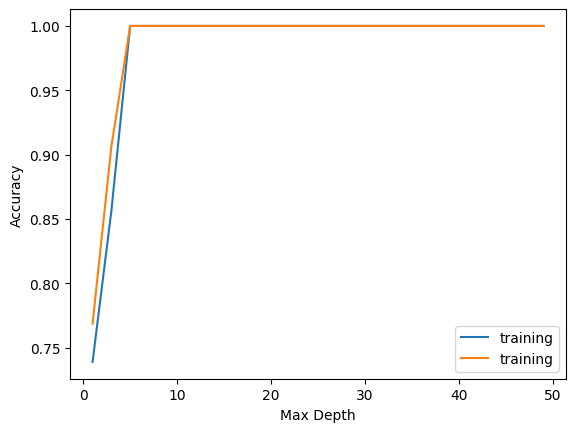

In [65]:
# Plot `depth_hyperparams`, `training_acc`
plt.plot(depth_hyperparams,training_acc,label="training")
plt.plot(depth_hyperparams,validation_acc,label="training")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend();

In [69]:
# Evaluating the model on test data
test_acc = model.score(X_test,y_test)
print("Test Accuracy:", round(test_acc, 2))

Test Accuracy: 0.98


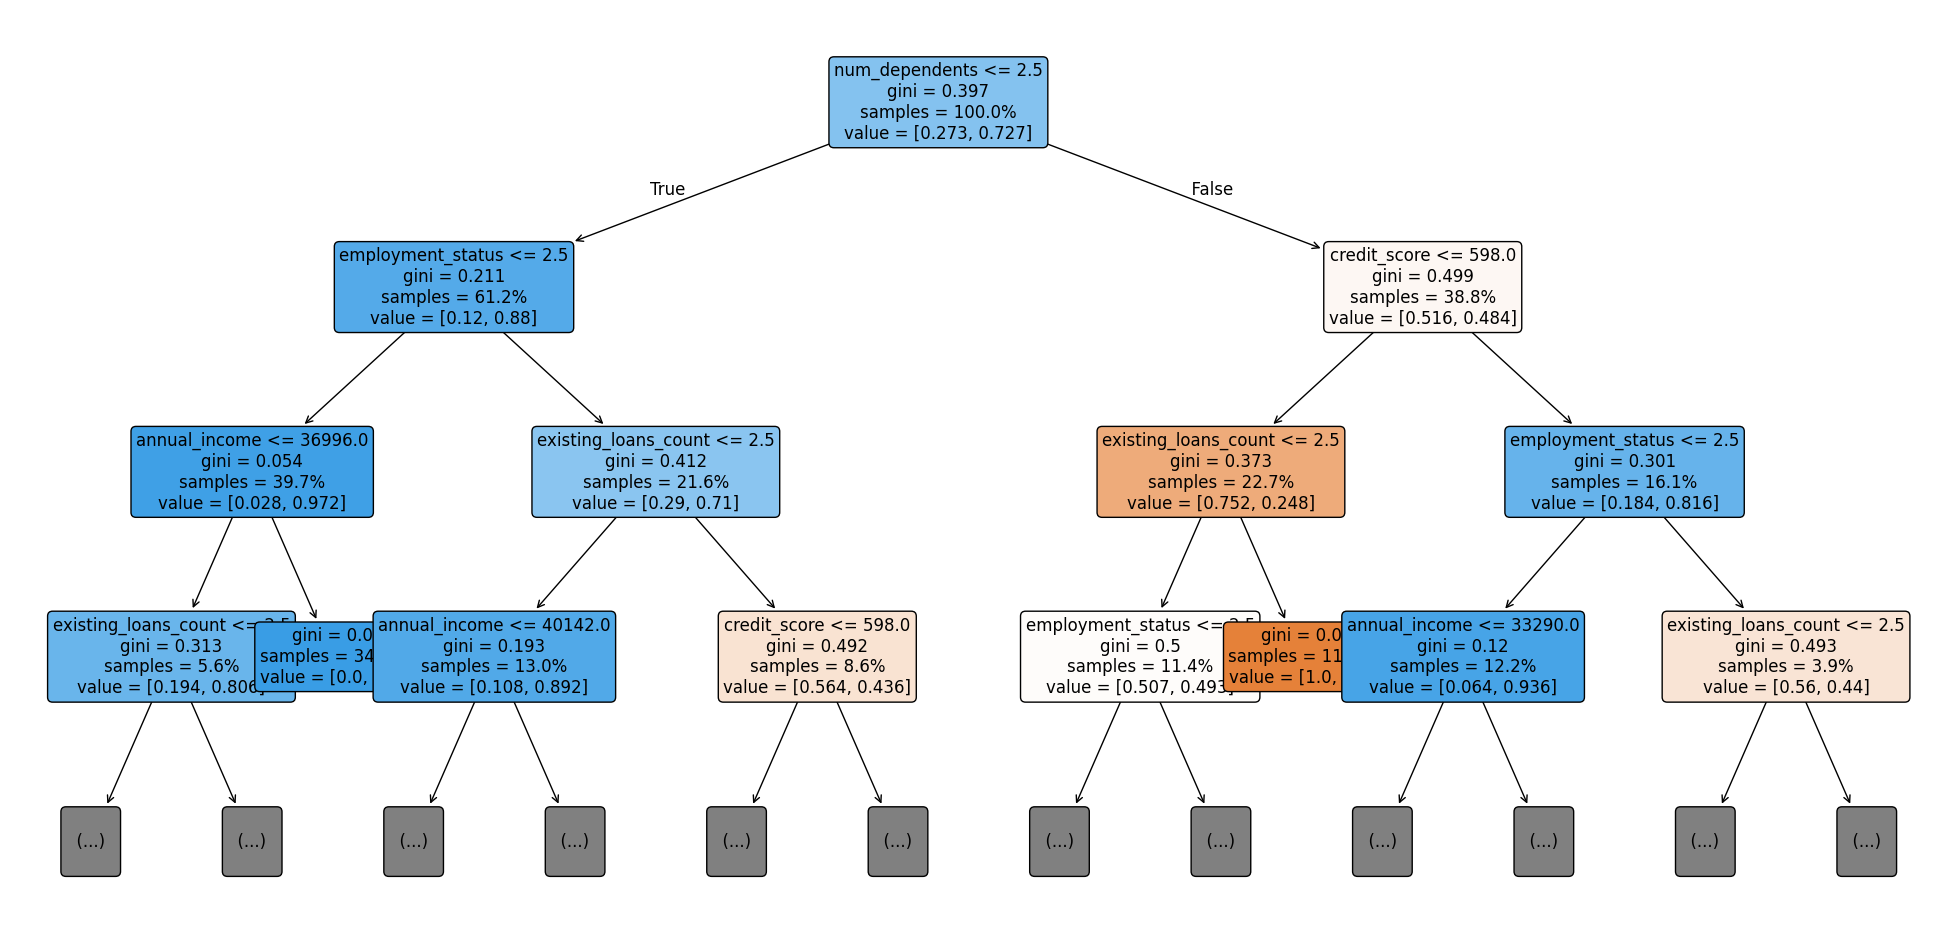

In [70]:
#Communicate results
fig, ax = plt.subplots(figsize=(25, 12))
# Plot tree
plot_tree(
    decision_tree = model.named_steps["decisiontreeclassifier"],
    feature_names = X_train.columns.to_list(),
    filled=True,  # Color leaf with class
    rounded=True,  # Round leaf edges
    proportion=True,  # Display proportion of classes in leaf
    max_depth=3,  # Only display first 3 levels
    fontsize=12,  # Enlarge font
    ax=ax,  # Place in figure axis
);

In [77]:
features = X_train.columns
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

feat_imp = pd.Series(importances,index=features).sort_values(ascending=True)
feat_imp

age                     0.000000
gender                  0.000000
marital_status          0.000000
loan_amount             0.000000
annual_income           0.140101
employment_status       0.177027
num_dependents          0.187562
existing_loans_count    0.204158
credit_score            0.291153
dtype: float64

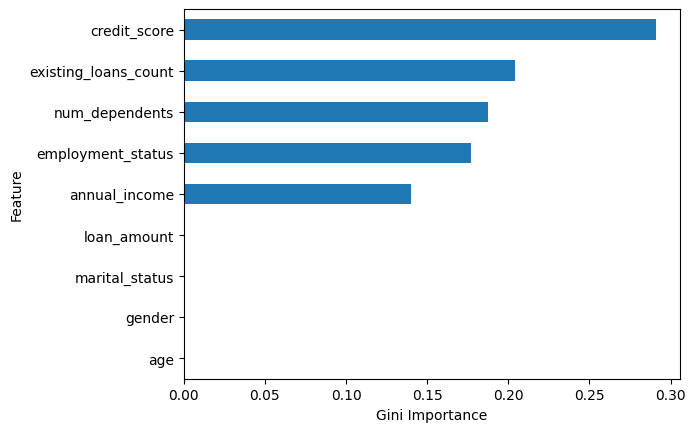

In [78]:
# Plot feature importance
feat_imp.plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature");